In [1]:
import nibabel as nib
from pathlib import Path
from server_specific.server_utils import get_patients
from main_preprocessing import preprocess_and_save_ccta_scans

from models.net_utils import get_best_device
from models.unet3D import UNet3D
import torch

from data.data_utils import get_preprocessed_patches, get_all_patches_with_certain_idx
from training_utils import predict_hidden_test_data

In [2]:
hidden_test_data_folder = Path("/data/test_set/")
hidden_test_patients = get_patients(folder_fp = hidden_test_data_folder)
print(len(hidden_test_patients))

200


In [3]:
# let's get all indexes
hidden_test_idxs = []
for hidden_test_patient in hidden_test_patients:
    hidden_test_idxs.append(hidden_test_patient.idx)
    
print(hidden_test_idxs)

['d26eae', 'e0f05d', 'e2fa8f', 'd6420a', 'f64f41', 'fc47b3', 'f6e0a1', 'c7ce48', 'd029fa', 'f8818b', 'd536a8', 'da4ea2', 'f6103c', 'caa1ae', 'eef79a', 'f32828', 'eb624d', 'fb84a9', 'fadb19', 'fe50b6', 'fc9e91', 'eaa068', 'd48ff4', 'd6e5a2', 'da4d43', 'e3d6c4', 'e5b861', 'd7cdaa', 'fc71f2', 'c83764', 'e4e549', 'd6a403', 'f74efa', 'f53f2f', 'd15e78', 'f369cb', 'e73cb1', 'f74787', 'd4735e', 'f7b856', 'f57e5c', 'c75cb6', 'd83c7e', 'eb3be2', 'f391e0', 'e6fcc0', 'd4e33e', 'fc56db', 'c6f3ac', 'cc6aed', 'c78961', 'db9351', 'da6813', 'fce86e', 'dcb5d6', 'f1607c', 'fd0f7e', 'dfe62e', 'f3457d', 'db3def', 'd3b913', 'fc95ce', 'e1bb74', 'e3f695', 'fa88d3', 'de5872', 'd6061b', 'dbb1de', 'd62a7b', 'efd96a', 'e29c9c', 'f24f1a', 'e6f47e', 'ee1a71', 'f4466a', 'd7be63', 'd72a11', 'eb1e33', 'ff2ccb', 'dcaada', 'f89f8d', 'fbb2a7', 'ca0cec', 'f5ca38', 'e888a6', 'dccb3c', 'dae40f', 'deeeb5', 'df156e', 'd2f483', 'd8d179', 'eaf89d', 'fa2b7a', 'f0cbba', 'f0bc31', 'ce7d91', 'd80eae', 'cebe3d', 'de482c', 'e629fa',

In [4]:
hidden_test_patient_patches_fp = Path("/group/gecko/pweinmann/mip_local_unet/hidden_test_patients_patches/")
# preprocess_and_save_ccta_scans(hidden_test_patients, output_dir = hidden_test_patient_patches_fp, image_only = True)

Now let's load the model

In [5]:
trained_model_path = "saved_models/3d_model20241216-101621.pth" # average dice score of 0.78
block_size = 128

In [6]:
device = get_best_device()

torch.set_default_device(device)
print(f"Using {device} device. Every tensor created will be by default on {device}")

model = UNet3D(in_channels=1, num_classes=1)

model.load_state_dict(torch.load(trained_model_path, weights_only=True))
model.to(device)
model.eval();

Using cuda device. Every tensor created will be by default on cuda


In [7]:
preprocessed_patches = get_preprocessed_patches(patches_folder = hidden_test_patient_patches_fp)
id_test_idx_patches_list = get_all_patches_with_certain_idx(hidden_test_idxs, preprocessed_patches)

print(len(id_test_idx_patches_list))

amt of detected patch files:  5424
200


selected threshold: 0.204305
processing hidden test patient 1 / 1, patient_id: e0f05d


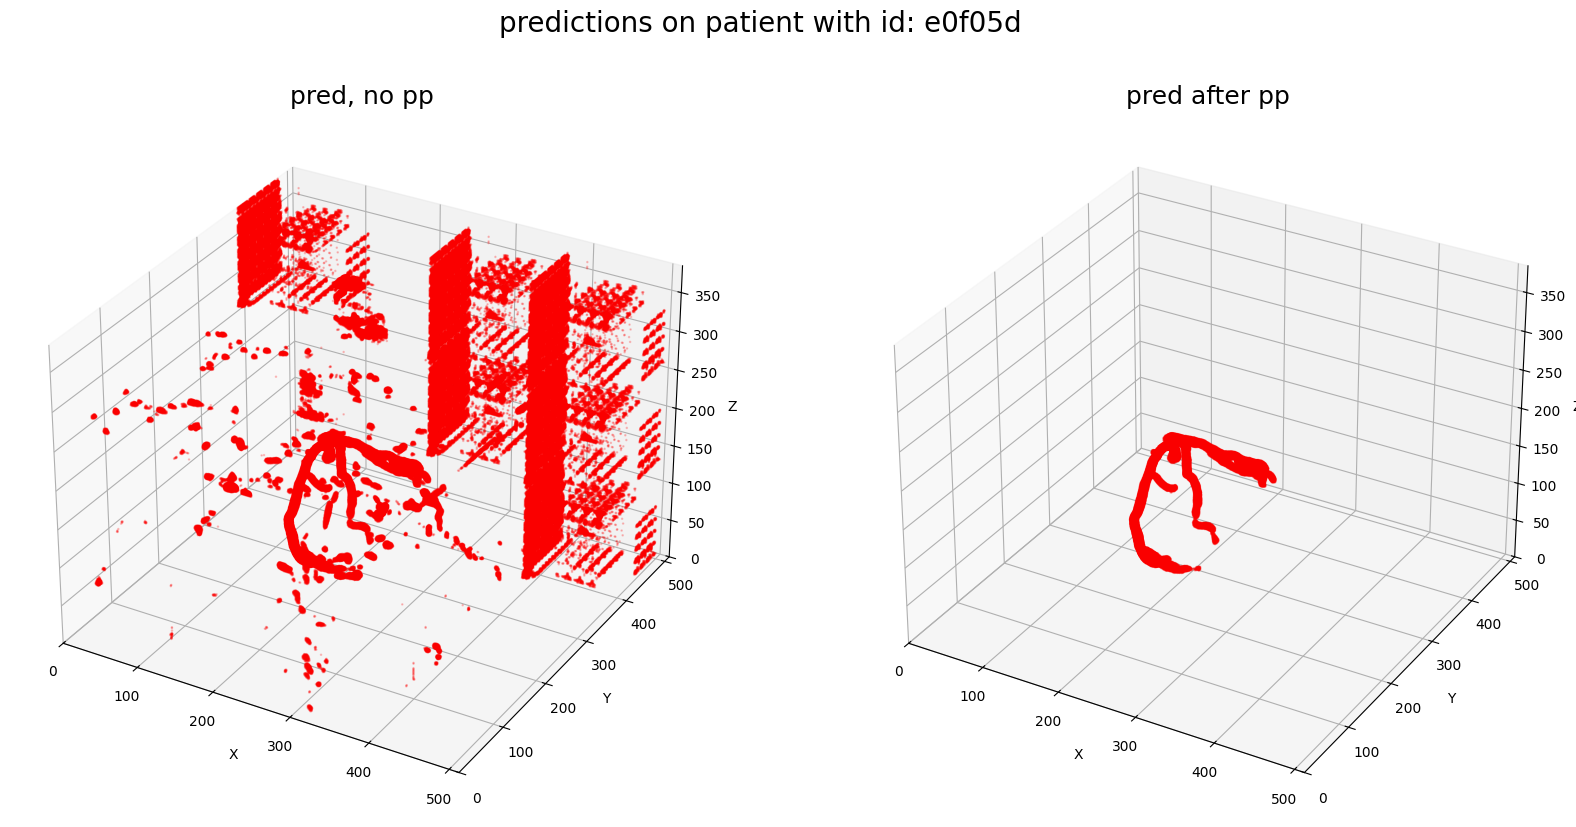

NameError: name 'plot_model_confidence' is not defined

In [8]:
threshold = 0.204305 # best thresold, but it barely makes a difference.

hidden_test_pred_fp = Path("/group/gecko/pweinmann/mip_local_unet/hidden_test_patients_predictions/")

predict_hidden_test_data([id_test_idx_patches_list[1]], model, threshold = threshold, visualize=True, out_dir = hidden_test_pred_fp);